<a href="https://colab.research.google.com/github/saifinuha/data-science-2026/blob/main/Pertemuan5_Saifin_Nuha_240401010257.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(891, 15) survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33


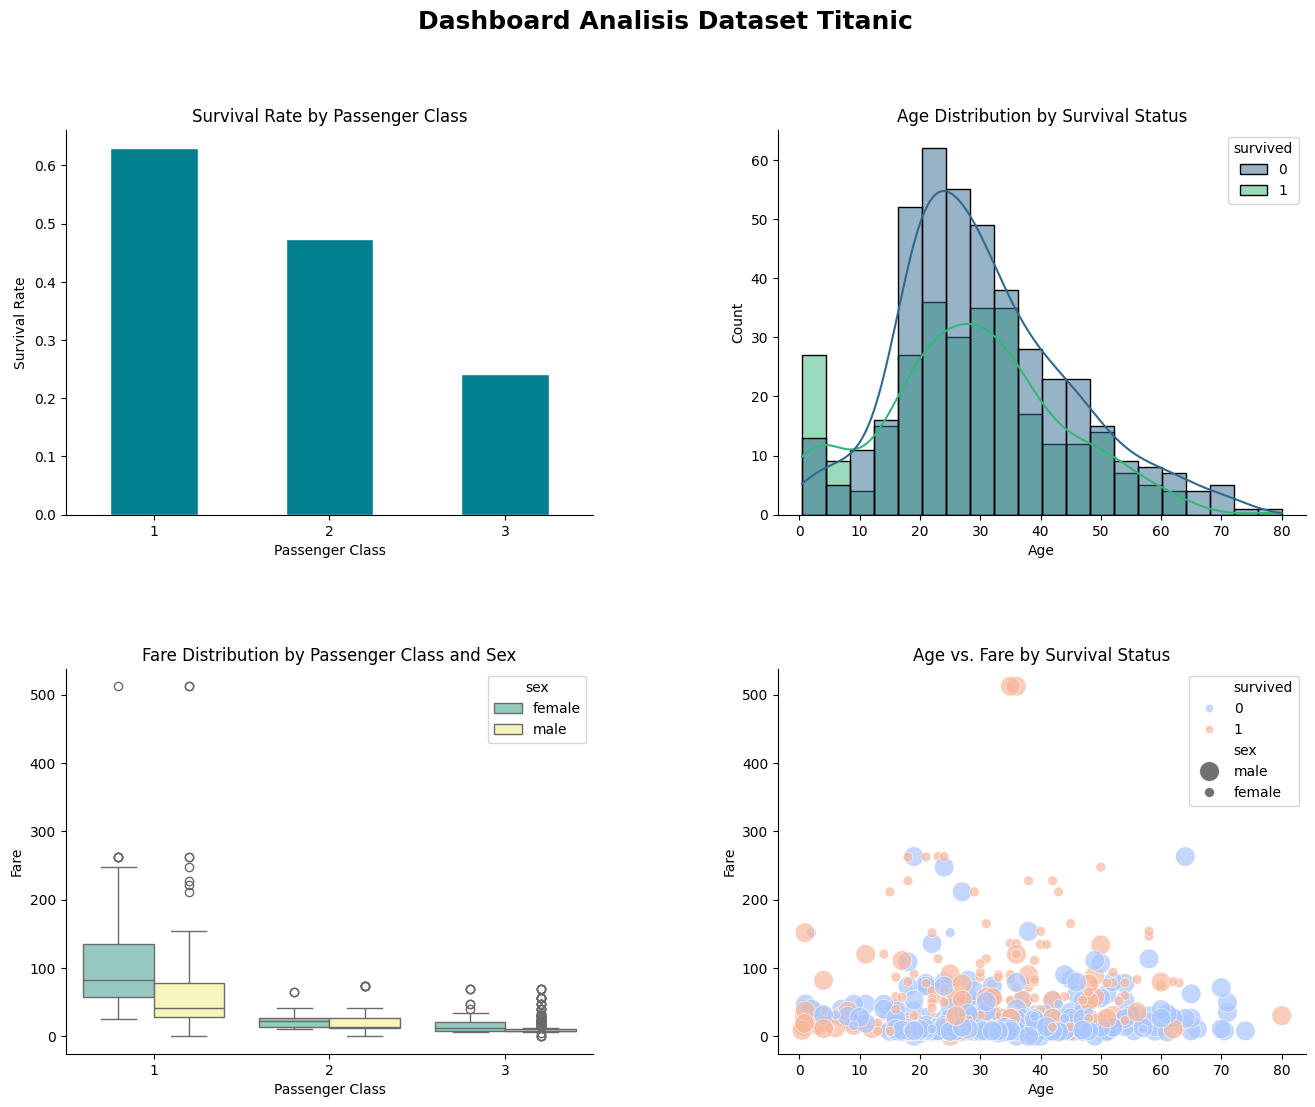

Dashboard tersimpan sebagai dashboard_titanic.png


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('titanic') # ganti sesuai pilihan
print(df.shape, df.dtypes)
print(df.describe().round(2))

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Titanic', # Updated title
              fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# ── 3. GRAFIK 1: Bar Chart (Survival Rate by Pclass) ───────────────────
survival_rate_pclass = df.groupby('pclass')['survived'].mean()
survival_rate_pclass.plot(kind='bar', ax=ax1, color='#028090',
                  edgecolor='white')
ax1.set_title('Survival Rate by Passenger Class')
ax1.set_xlabel('Passenger Class'); ax1.set_ylabel('Survival Rate')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE (Age Distribution by Survival) ────────
sns.histplot(data=df, x='age', hue='survived', kde=True, palette='viridis', ax=ax2)
ax2.set_title('Age Distribution by Survival Status')
ax2.set_xlabel('Age'); ax2.set_ylabel('Count')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot (Fare Distribution by Pclass and Sex) ─────────
sns.boxplot(data=df, x='pclass', y='fare', hue='sex', palette='Set3', ax=ax3)
ax3.set_title('Fare Distribution by Passenger Class and Sex')
ax3.set_xlabel('Passenger Class'); ax3.set_ylabel('Fare')
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot (Age vs. Fare by Survival Status) ───────
sns.scatterplot(data=df, x='age', y='fare',
hue='survived', size='sex', sizes=(50,200),
palette='coolwarm', alpha=0.7, ax=ax4)
ax4.set_title('Age vs. Fare by Survival Status')
ax4.set_xlabel('Age'); ax4.set_ylabel('Fare')
ax4.spines[['top','right']].set_visible(False)

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_titanic.png')

### Analisis Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang (Pclass)

**What?** Grafik batang ini menunjukkan tingkat kelangsungan hidup rata-rata penumpang di setiap kelas (`pclass`). Terlihat bahwa penumpang di `pclass` 1 memiliki tingkat kelangsungan hidup tertinggi sebesar sekitar **63%**. Disusul oleh `pclass` 2 dengan sekitar **47%**, dan `pclass` 3 memiliki tingkat kelangsungan hidup terendah, yaitu sekitar **24%**.

**So what?** Data ini mengindikasikan adanya hubungan yang jelas antara kelas sosial atau ekonomi penumpang dengan peluang mereka untuk bertahan hidup. Penumpang kelas satu mungkin memiliki akses lebih baik ke sekoci penyelamat atau fasilitas keselamatan lainnya, yang secara signifikan meningkatkan peluang mereka untuk selamat.

**Now what?** Investigasi lebih lanjut dapat dilakukan untuk memahami faktor-faktor spesifik (misalnya, lokasi kabin, prioritas evakuasi) yang berkontribusi pada perbedaan tingkat kelangsungan hidup antar kelas. Perlu juga dilihat apakah gender atau usia memainkan peran berbeda dalam setiap kelas.

### Distribusi Usia Berdasarkan Status Kelangsungan Hidup

**What?** Histogram dengan estimasi kepadatan kernel (KDE) ini menggambarkan distribusi usia penumpang, dibedakan antara mereka yang selamat (`survived = 1`) dan yang tidak selamat (`survived = 0`). Distribusi untuk korban yang tidak selamat tampak lebih terkonsentrasi pada rentang usia **20-40 tahun**, sedangkan yang selamat menunjukkan distribusi yang lebih merata, namun dengan puncak yang lebih tinggi pada usia yang lebih muda (anak-anak) dan sekitar usia **20-30 tahun**.

**So what?** Pola ini menunjukkan bahwa usia mungkin menjadi faktor penting dalam kelangsungan hidup. Ada indikasi bahwa anak-anak memiliki tingkat kelangsungan hidup yang lebih tinggi, mungkin karena "wanita dan anak-anak dahulu" menjadi prioritas. Sementara itu, penumpang usia produktif (20-40 tahun) cenderung memiliki jumlah korban yang tidak selamat lebih banyak.

**Now what?** Akan menarik untuk melihat distribusi usia ini dipadukan dengan jenis kelamin (`sex`) dan kelas penumpang (`pclass`) untuk mengidentifikasi kelompok usia mana yang paling rentan atau paling beruntung. Analisis lebih dalam tentang rentang usia tertentu juga bisa memberikan wawasan lebih lanjut.

### Distribusi Tarif (Fare) Berdasarkan Kelas Penumpang dan Jenis Kelamin

**What?** Boxplot ini menunjukkan distribusi tarif yang dibayar penumpang (`fare`), dikelompokkan berdasarkan kelas penumpang (`pclass`) dan jenis kelamin (`sex`). Terlihat jelas bahwa penumpang `pclass` 1 membayar tarif yang jauh lebih tinggi dibandingkan `pclass` 2 dan 3. Rentang tarif juga sangat lebar di `pclass` 1, dengan beberapa outlier yang membayar sangat mahal. Ada sedikit perbedaan median tarif antara pria dan wanita dalam setiap kelas, meskipun di `pclass` 1, median tarif wanita terlihat sedikit lebih tinggi.

**So what?** Tarif yang dibayar secara langsung berkorelasi dengan kelas penumpang, yang selanjutnya berkorelasi dengan status sosial dan fasilitas yang diterima. Variasi tarif yang besar di kelas satu menunjukkan adanya akomodasi yang sangat mewah. Perbedaan kecil antara pria dan wanita dalam tarif mengindikasikan bahwa harga tiket tidak terlalu bergantung pada gender tetapi lebih pada kelas perjalanan.

**Now what?** Bisa diselidiki apakah tarif yang sangat tinggi atau sangat rendah dalam suatu kelas memiliki pengaruh terhadap tingkat kelangsungan hidup. Juga, dapat dianalisis bagaimana faktor `embarked` (pelabuhan keberangkatan) memengaruhi tarif dan hubungannya dengan kelas penumpang.

### Hubungan Usia dan Tarif Berdasarkan Status Kelangsungan Hidup

**What?** Scatter plot ini memvisualisasikan hubungan antara usia (`age`) dan tarif (`fare`) yang dibayar oleh penumpang, dengan titik-titik diwarnai berdasarkan status kelangsungan hidup (`survived`) dan ukurannya berdasarkan jenis kelamin (`sex`). Terlihat ada konsentrasi korban yang tidak selamat (titik merah) di antara penumpang usia muda hingga paruh baya yang membayar tarif rendah. Penumpang yang selamat (titik biru) lebih tersebar, tetapi ada kelompok yang selamat di `pclass` 1 (tarif tinggi) tanpa memandang usia.

**So what?** Plot ini menyoroti bahwa kombinasi usia muda/paruh baya dan tarif rendah (kemungkinan besar `pclass` 3) memiliki risiko kematian yang lebih tinggi. Sebaliknya, membayar tarif tinggi (mengindikasikan `pclass` 1) tampaknya memberikan peluang kelangsungan hidup yang lebih baik, terlepas dari usia. Ukuran titik yang berbeda untuk pria dan wanita juga memungkinkan kita melihat bagaimana gender terdistribusi dalam kelompok ini.

**Now what?** Untuk analisis lebih mendalam, dapat dilakukan segmentasi data berdasarkan kuartil tarif atau kelompok usia tertentu untuk melihat pola kelangsungan hidup yang lebih spesifik. Perlu juga ditambahkan garis tren atau kepadatan untuk area yang padat untuk mendapatkan pemahaman yang lebih baik tentang hubungan ini.